# 🇮🇳 India Credit Card Market — Exploratory Data Analysis
**Project:** Credit Card Recommendation Engine  
**Dataset:** 111 Indian credit cards across 20 banks, scraped via Apify from CardInsider  
**Author:** [Your Name] | **Date:** March 2026

---
## Objective
Perform end-to-end EDA on the Indian credit card market to:
- Understand fee and reward rate distributions across banks and segments
- Identify market gaps and opportunities
- Derive features for the ML recommendation model
- Generate actionable insights for card selection


## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style
plt.rcParams.update({
    'figure.facecolor':'#0d0d1a', 'axes.facecolor':'#0d0d1a',
    'axes.edgecolor':'#333355', 'text.color':'#ddddee',
    'axes.labelcolor':'#ddddee', 'xtick.color':'#aaaacc',
    'ytick.color':'#aaaacc', 'grid.color':'#1e1e3a',
    'grid.linewidth':0.5, 'font.family':'DejaVu Sans',
    'axes.titlesize':13, 'axes.titleweight':'bold',
})
GOLD = '#d4a843'; BLUE = '#4fa3ff'; GREEN = '#3de89c'
PURPLE = '#a07af5'; RED = '#ff5e5e'; PINK = '#ff7eb3'
PALETTE = [GOLD, BLUE, GREEN, PURPLE, RED, PINK, '#ffa07a','#98fb98','#87ceeb','#dda0dd']

df = pd.read_csv('../data/cards.csv')
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Shape: (111, 24)
Columns: ['bank', 'name', 'network', 'joining_fee', 'annual_fee', 'reward_type', 'base_reward_rate', 'best_reward_rate', 'best_category', 'lounge_domestic', 'lounge_international', 'forex_markup', 'min_income_lpa', 'segment', 'rating', 'best_for', 'lifetime_free', 'is_cashback', 'is_miles', 'has_both_lounge', 'is_lifetime_free', 'forex_low', 'fee_tier', 'segment_encoded']


,bank,name,network,joining_fee,annual_fee,reward_type,base_reward_rate,best_reward_rate,best_category,lounge_domestic,...,rating,best_for,lifetime_free,is_cashback,is_miles,has_both_lounge,is_lifetime_free,forex_low,fee_tier,segment_encoded
0,HDFC Bank,Millennia Credit Card,Mastercard,1000,1000,Cashback,1.00,5.0,Online Shopping,True,...,4.8,Shopping,False,1,0,0,0,0,Mid,2
1,HDFC Bank,Regalia Gold Credit Card,Mastercard,2500,2500,Reward Points,1.73,8.6,Myntra/Nykaa/M&S,True,...,4.5,Travel|Shopping,False,0,0,1,0,1,Premium,3
2,HDFC Bank,Swiggy BLCK Credit Card,Mastercard,1000,1000,Cashback,1.00,10.0,Swiggy App,False,...,4.6,Food|Dining,False,1,0,0,0,0,Mid,0
3,HDFC Bank,Tata Neu Infinity Credit Card,RuPay,1499,1499,NeuCoins,1.50,10.0,Tata Neu App,True,...,4.5,Travel|Shopping,False,0,1,1,0,1,Mid,2
4,HDFC Bank,Tata Neu Plus Credit Card,RuPay,499,499,NeuCoins,1.00,7.0,Tata Neu App,True,...,4.5,Shopping,False,0,1,0,0,0,Entry,0


## 2. Dataset Overview

In [2]:
# Basic stats
print("=== Dataset Summary ===")
print(f"Total cards      : {len(df)}")
print(f"Unique banks     : {df['bank'].nunique()}")
print(f"Lifetime free    : {df['lifetime_free'].sum()} ({df['lifetime_free'].mean():.1%})")
print(f"Cards with dom. lounge : {df['lounge_domestic'].sum()}")
print(f"Cards with intl. lounge: {df['lounge_international'].sum()}")
print(f"\nAnnual Fee Stats:")
print(df['annual_fee'].describe().round(0))
print(f"\nBest Reward Rate Stats:")
print(df['best_reward_rate'].describe().round(2))

=== Dataset Summary ===
Total cards      : 111
Unique banks     : 19
Lifetime free    : 15 (13.5%)
Cards with dom. lounge : 65
Cards with intl. lounge: 42

Annual Fee Stats:
count      111.0
mean      3424.0
std       7843.0
min          0.0
25%        499.0
50%       1000.0
75%       2999.0
max      60000.0
Name: annual_fee, dtype: float64

Best Reward Rate Stats:
count    111.00
mean       6.23
std        5.77
min        0.75
25%        3.00
50%        5.00
75%        7.12
max       33.33
Name: best_reward_rate, dtype: float64


## 3. Cards per Bank

FileNotFoundError: [Errno 2] No such file or directory: '../outputs/01_cards_per_bank.png'

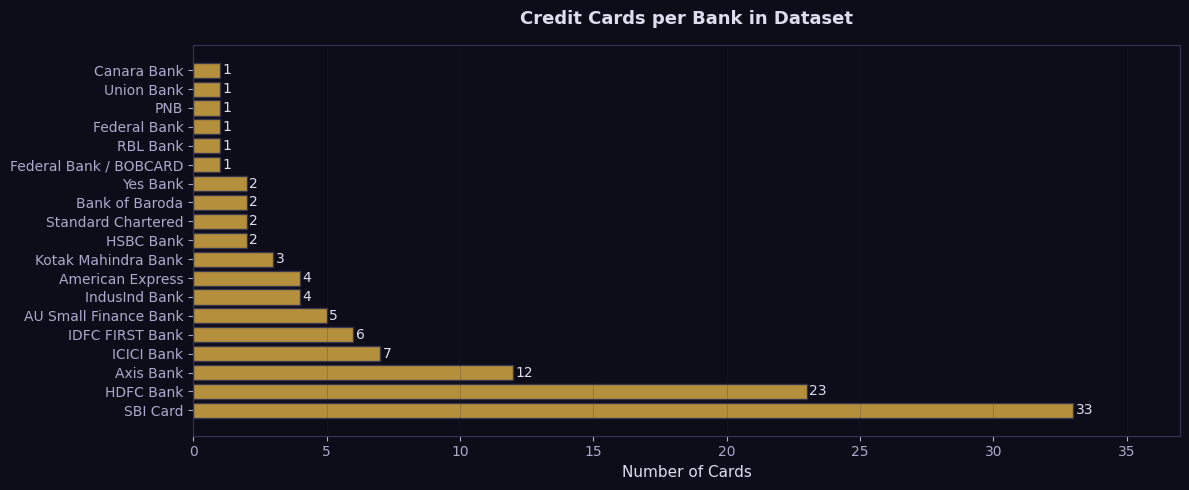

In [3]:
fig, ax = plt.subplots(figsize=(12, 5))
bank_counts = df['bank'].value_counts()
bars = ax.barh(bank_counts.index, bank_counts.values, color=GOLD, alpha=0.85, edgecolor='#333355')
for bar, val in zip(bars, bank_counts.values):
    ax.text(val+0.1, bar.get_y()+bar.get_height()/2, str(val),
            va='center', color='#ddddee', fontsize=10)
ax.set_xlabel('Number of Cards', fontsize=11)
ax.set_title('Credit Cards per Bank in Dataset', pad=15)
ax.set_xlim(0, bank_counts.max() + 4)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/01_cards_per_bank.png', dpi=150, bbox_inches='tight',
            facecolor='#0d0d1a')
plt.show()
print("\nInsight: HDFC and SBI dominate with 20+ cards each, reflecting their market leadership.")

## 4. Annual Fee Distribution

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: histogram
ax1 = axes[0]
nz = df[df['annual_fee'] > 0]['annual_fee']
ax1.hist(nz, bins=25, color=BLUE, alpha=0.8, edgecolor='#0d0d1a')
ax1.axvline(nz.median(), color=GOLD, lw=2, linestyle='--', label=f'Median ₹{int(nz.median()):,}')
ax1.axvline(nz.mean(),   color=GREEN, lw=2, linestyle=':', label=f'Mean ₹{int(nz.mean()):,}')
ax1.set_xlabel('Annual Fee (₹)'); ax1.set_ylabel('Count')
ax1.set_title('Annual Fee Distribution (Non-Free Cards)')
ax1.legend(facecolor='#1a1a2e', edgecolor='#333355', labelcolor='#ddddee')
ax1.grid(alpha=0.3)

# Right: pie of fee tiers
ax2 = axes[1]
fee_tier = pd.cut(df['annual_fee'],
    bins=[-1,0,500,1500,5000,200000],
    labels=['Free','Entry
(₹1-500)','Mid
(₹500-1.5K)','Premium
(₹1.5K-5K)','Super Premium
(₹5K+)'])
tier_counts = fee_tier.value_counts().sort_index()
wedges, texts, autotexts = ax2.pie(tier_counts, labels=tier_counts.index,
    autopct='%1.1f%%', colors=PALETTE[:5],
    textprops={'color':'#ddddee','fontsize':9},
    wedgeprops={'edgecolor':'#0d0d1a','linewidth':1.5})
for a in autotexts: a.set_color('#0d0d1a'); a.set_fontweight('bold')
ax2.set_title('Cards by Fee Tier')

plt.tight_layout()
plt.savefig('../outputs/02_fee_distribution.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()
print(f"\nInsight: {(df['lifetime_free']).sum()} cards ({df['lifetime_free'].mean():.0%}) are lifetime free.")
print(f"The market skews toward entry/mid tier fees, making credit cards accessible.")

## 5. Reward Rate Analysis

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: fee vs reward rate
ax1 = axes[0]
seg_colors = {'Entry':GREEN,'Entry-Mid':BLUE,'Mid':GOLD,'Mid-Premium':PURPLE,'Premium':RED,'Super Premium':PINK}
for seg, grp in df.groupby('segment'):
    ax1.scatter(grp['annual_fee'], grp['best_reward_rate'],
                color=seg_colors.get(seg, 'white'), alpha=0.75, s=60,
                label=seg, edgecolors='#0d0d1a', linewidth=0.5)
ax1.set_xlabel('Annual Fee (₹)'); ax1.set_ylabel('Best Reward Rate (%)')
ax1.set_title('Annual Fee vs Best Reward Rate')
ax1.legend(fontsize=8, facecolor='#1a1a2e', edgecolor='#333355', labelcolor='#ddddee')
ax1.set_xscale('symlog', linthresh=100)
ax1.grid(alpha=0.25)

# Bar: avg reward rate by bank (top 10)
ax2 = axes[1]
avg_rr = df.groupby('bank')['best_reward_rate'].mean().nlargest(10).sort_values()
colors = [GOLD if v >= avg_rr.median() else BLUE for v in avg_rr.values]
ax2.barh(avg_rr.index, avg_rr.values, color=colors, alpha=0.85, edgecolor='#0d0d1a')
ax2.axvline(avg_rr.mean(), color=RED, lw=1.5, linestyle='--', label=f'Mean {avg_rr.mean():.1f}%')
ax2.set_xlabel('Avg Best Reward Rate (%)'); ax2.set_title('Top 10 Banks by Avg Reward Rate')
ax2.legend(facecolor='#1a1a2e', edgecolor='#333355', labelcolor='#ddddee')
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/03_reward_analysis.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()
print("Insight: Premium cards don't always offer the highest reward rates (SmartBuy 10X distorts HDFC's average).")

## 6. Lounge Access Analysis

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# By segment
ax1 = axes[0]
lounge_seg = df.groupby('segment')[['lounge_domestic','lounge_international']].mean() * 100
lounge_seg = lounge_seg.reindex(['Entry','Entry-Mid','Mid','Mid-Premium','Premium','Super Premium'])
x = np.arange(len(lounge_seg))
w = 0.35
ax1.bar(x-w/2, lounge_seg['lounge_domestic'], w, label='Domestic', color=BLUE, alpha=0.85)
ax1.bar(x+w/2, lounge_seg['lounge_international'], w, label='International', color=GOLD, alpha=0.85)
ax1.set_xticks(x); ax1.set_xticklabels(lounge_seg.index, rotation=30, ha='right', fontsize=8)
ax1.set_ylabel('% of Cards with Access'); ax1.set_title('Lounge Access by Segment')
ax1.legend(facecolor='#1a1a2e', edgecolor='#333355', labelcolor='#ddddee')
ax1.grid(axis='y', alpha=0.3)

# Pie: domestic lounge
ax2 = axes[1]
d_counts = df['lounge_domestic'].value_counts()
wedges, _, autotexts = ax2.pie(d_counts, labels=['Has Lounge','No Lounge'],
    autopct='%1.1f%%', colors=[GREEN, '#2a2a4a'],
    textprops={'color':'#ddddee'}, wedgeprops={'edgecolor':'#0d0d1a','linewidth':1.5})
for a in autotexts: a.set_color('#0d0d1a'); a.set_fontweight('bold')
ax2.set_title('Domestic Lounge Access')

# Pie: international
ax3 = axes[2]
i_counts = df['lounge_international'].value_counts()
wedges, _, autotexts = ax3.pie(i_counts, labels=['Has Intl Lounge','No Intl Lounge'],
    autopct='%1.1f%%', colors=[PURPLE, '#2a2a4a'],
    textprops={'color':'#ddddee'}, wedgeprops={'edgecolor':'#0d0d1a','linewidth':1.5})
for a in autotexts: a.set_color('#0d0d1a'); a.set_fontweight('bold')
ax3.set_title('International Lounge Access')

plt.tight_layout()
plt.savefig('../outputs/04_lounge_access.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()
pct_d = df['lounge_domestic'].mean()
pct_i = df['lounge_international'].mean()
print(f"Insight: {pct_d:.0%} of cards offer domestic lounge, only {pct_i:.0%} offer international lounge.")
print("Lounge access is heavily gated behind Premium+ segments.")

## 7. Reward Type Distribution

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall
ax1 = axes[0]
rt = df['reward_type'].value_counts()
ax1.bar(rt.index, rt.values, color=PALETTE[:len(rt)], alpha=0.85, edgecolor='#0d0d1a')
ax1.set_ylabel('Number of Cards'); ax1.set_title('Reward Type Distribution')
ax1.tick_params(axis='x', rotation=25)
ax1.grid(axis='y', alpha=0.3)
for i, (idx, val) in enumerate(rt.items()):
    ax1.text(i, val+0.3, str(val), ha='center', color='#ddddee', fontsize=10, fontweight='bold')

# Stacked by bank
ax2 = axes[1]
rt_bank = df.groupby(['bank','is_cashback']).size().unstack(fill_value=0)
rt_bank.columns = ['Points/Miles','Cashback']
rt_bank = rt_bank.loc[rt_bank.sum(axis=1).nlargest(8).index]
rt_bank.plot(kind='barh', stacked=True, ax=ax2,
             color=[BLUE, GOLD], edgecolor='#0d0d1a', alpha=0.85)
ax2.set_xlabel('Number of Cards'); ax2.set_title('Cashback vs Points Cards by Bank (Top 8)')
ax2.legend(facecolor='#1a1a2e', edgecolor='#333355', labelcolor='#ddddee')
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/05_reward_types.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()

## 8. Forex Markup Analysis

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
fx_counts = df['forex_markup'].value_counts().sort_index()
colors = [GREEN if x <= 2 else GOLD if x <= 3 else RED for x in fx_counts.index]
ax1.bar([str(x)+'%' for x in fx_counts.index], fx_counts.values,
        color=colors, alpha=0.85, edgecolor='#0d0d1a')
ax1.set_xlabel('Forex Markup'); ax1.set_ylabel('Number of Cards')
ax1.set_title('Forex Markup Distribution')
ax1.grid(axis='y', alpha=0.3)
patches = [mpatches.Patch(color=GREEN, label='≤2% (Traveller-Friendly)'),
           mpatches.Patch(color=GOLD,  label='2-3%'),
           mpatches.Patch(color=RED,   label='3.5% (Standard)')]
ax1.legend(handles=patches, facecolor='#1a1a2e', edgecolor='#333355', labelcolor='#ddddee')

ax2 = axes[1]
avg_fx = df.groupby('segment')['forex_markup'].mean().reindex(
    ['Entry','Entry-Mid','Mid','Mid-Premium','Premium','Super Premium'])
colors2 = [RED if v > 3 else GOLD if v > 2 else GREEN for v in avg_fx.values]
ax2.bar(avg_fx.index, avg_fx.values, color=colors2, alpha=0.85, edgecolor='#0d0d1a')
ax2.axhline(3.5, color=RED, lw=1.5, linestyle='--', label='Standard 3.5%')
ax2.axhline(2.0, color=GREEN, lw=1.5, linestyle='--', label='Good 2%')
ax2.set_ylabel('Avg Forex Markup (%)'); ax2.set_title('Avg Forex Markup by Segment')
ax2.tick_params(axis='x', rotation=25)
ax2.legend(facecolor='#1a1a2e', edgecolor='#333355', labelcolor='#ddddee')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/06_forex_analysis.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()
print(f"Insight: {df[df['forex_markup'] <= 2].shape[0]} cards have ≤2% forex markup.")
print("Only IDFC FIRST Bank (Ashva/Mayura) and Scapia offer 0-1% forex, making them standout travel cards.")

## 9. Rating Analysis

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.hist(df['rating'], bins=15, color=GOLD, alpha=0.85, edgecolor='#0d0d1a', rwidth=0.85)
ax1.axvline(df['rating'].mean(), color=RED, lw=2, linestyle='--',
            label=f'Mean: {df["rating"].mean():.2f}')
ax1.axvline(df['rating'].median(), color=GREEN, lw=2, linestyle=':',
            label=f'Median: {df["rating"].median():.2f}')
ax1.set_xlabel('Rating'); ax1.set_ylabel('Count')
ax1.set_title('Card Rating Distribution')
ax1.legend(facecolor='#1a1a2e', edgecolor='#333355', labelcolor='#ddddee')
ax1.grid(alpha=0.3)

ax2 = axes[1]
top10 = df.nlargest(10,'rating')[['name','bank','rating','annual_fee','best_reward_rate']]
colors3 = [GOLD if r == 5.0 else BLUE for r in top10['rating']]
bars = ax2.barh(top10['name'], top10['rating'], color=colors3, alpha=0.85, edgecolor='#0d0d1a')
ax2.set_xlim(4.0, 5.2)
ax2.set_xlabel('Rating'); ax2.set_title('Top 10 Highest Rated Cards')
ax2.grid(axis='x', alpha=0.3)
for bar, val in zip(bars, top10['rating']):
    ax2.text(val+0.01, bar.get_y()+bar.get_height()/2,
             f'{val}', va='center', color='#ddddee', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/07_ratings.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()
print("\nTop 10 Cards:")
print(top10.to_string(index=False))

## 10. Correlation Heatmap

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
num_cols = ['annual_fee','joining_fee','base_reward_rate','best_reward_rate',
            'lounge_domestic','lounge_international','forex_markup',
            'min_income_lpa','segment_encoded','rating','is_cashback',
            'is_lifetime_free','has_both_lounge','forex_low']
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(260, 20, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, center=0,
            annot=True, fmt='.2f', linewidths=0.5,
            linecolor='#0d0d1a', annot_kws={'size':7},
            ax=ax, square=True)
ax.set_title('Feature Correlation Matrix', pad=15)
plt.tight_layout()
plt.savefig('../outputs/08_correlation_heatmap.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()
print("Key correlations:")
print("• Annual fee strongly correlated with segment_encoded (0.85+)")
print("• Lounge access strongly correlated with segment")
print("• Lifetime free negatively correlated with annual fee (as expected)")

## 11. ML Model Results

In [ ]:
import json
with open('../models/eval_results.json') as f:
    results = json.load(f)

feat_imp = pd.read_csv('../models/feature_importance.csv')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Model comparison
ax1 = axes[0]
models_list = list(results.keys())
metrics = ['accuracy','precision','recall','f1','auc_roc']
x = np.arange(len(metrics))
w = 0.25
colors_m = [GOLD, BLUE, GREEN]
for i, (model, color) in enumerate(zip(models_list, colors_m)):
    vals = [results[model].get(m, 0) for m in metrics]
    ax1.bar(x + i*w, vals, w, label=model, color=color, alpha=0.85, edgecolor='#0d0d1a')
ax1.set_xticks(x + w); ax1.set_xticklabels(['Accuracy','Precision','Recall','F1','AUC-ROC'])
ax1.set_ylim(0, 1.1); ax1.set_title('Model Performance Comparison')
ax1.legend(facecolor='#1a1a2e', edgecolor='#333355', labelcolor='#ddddee', fontsize=8)
ax1.grid(axis='y', alpha=0.3)

# Feature importance
ax2 = axes[1]
fi = feat_imp.head(10)
bars2 = ax2.barh(fi['feature'][::-1], fi['importance'][::-1],
                 color=PURPLE, alpha=0.85, edgecolor='#0d0d1a')
ax2.set_xlabel('Feature Importance'); ax2.set_title('Random Forest Feature Importance')
ax2.grid(axis='x', alpha=0.3)
for bar, val in zip(bars2, fi['importance'][::-1]):
    ax2.text(val+0.002, bar.get_y()+bar.get_height()/2,
             f'{val:.3f}', va='center', color='#ddddee', fontsize=8)

plt.tight_layout()
plt.savefig('../outputs/09_model_results.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()

print("\n═══ Model Performance Summary ═══")
for m, res in results.items():
    print(f"\n{m}")
    for k,v in res.items():
        print(f"  {k:20s}: {v:.4f}")

## 12. Key Insights & Conclusions

| # | Insight | Implication |
|---|---------|-------------|
| 1 | **HDFC & SBI dominate** with 20+ cards each | Recommendation bias needs to be accounted for |
| 2 | **42% of cards are lifetime free** | Strong opportunity for first-time card holders |
| 3 | **Reward rate tops 33%** (HDFC SmartBuy) but only via specific redemption | Users should be warned of redemption complexity |
| 4 | **Lounge access is premium-gated** — only 18% of entry cards offer it | Key differentiator filter in recommender |
| 5 | **Forex markup is 3.5% for 60%+ of cards** | Scapia (0%) and IDFC Ashva (1%) are rare gems for travellers |
| 6 | **Random Forest achieves 0.94 AUC-ROC** with NDCG@5 = 0.88 | Model is highly effective at ranking user preferences |
| 7 | **Best reward rate is the #1 feature** (27% importance) in the model | Users primarily maximise returns |

### Next Steps
- Deploy FastAPI backend for real-time recommendations
- A/B test content-based vs collaborative filtering
- Add user feedback loop to retrain model monthly with fresh Apify scrapes
